**Project **Objective**

This project aims to demonstrate the usability of an LLM as a judge or classifier. A small dataset was used due to the computational cost of running the llama3:8b model from Ollama locally.

It is important to note that the goal is not to evaluate the model’s performance, as the dataset size is not sufficient for a robust assessment. The dataset was obtained from Kaggle.

**DataFrame Creation**

A DataFrame was created containing 5 positive and 5 negative examples to validate whether the LLM correctly understood the provided instructions.

**Calling the LLM**

The model was executed using Ollama with a structured prompt that defines:
the expected inputs
the role the LLM should assume
the objective of the task
the comment to be evaluated
labeling rules
instructions
and the expected output format, which in this case is "positive" or "negative"

**Conclusion**

The LLM correctly classified 9 out of the 10 evaluated cases and followed the required output format in all responses.

This result suggests that this approach can be scaled to larger datasets, not only for sentiment analysis but also for various types of text classification tasks.

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#DataFrame

df = pd.read_csv("C:\\Users\\Clayton Miranda\\Desktop\\Modelos\\Datasets\\Youtube_comments z\\YoutubeCommentsDataSet.csv")

In [ ]:
# DF - Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


In [ ]:
# DF - Value Counts

df['Sentiment'].value_counts()

Sentiment
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64

In [ ]:
# # New DF with 5 positive examples and 5 negative examples

df_pos = df[df["Sentiment"] == "positive"].sample(n=5, random_state=42)

df_neg = df[df["Sentiment"] == "negative"].sample(n=5, random_state=42)

df_sample = pd.concat([df_pos, df_neg])

df_sample['Sentiment'].value_counts()

Sentiment
positive    5
negative    5
Name: count, dtype: int64

In [61]:
# Calling the LLM model

responses = []

for comment in df_sample["Comment"]:
    
    prompt = f"""
    # Inputs:
    * Persona and objective: Define what your goal is in this task.
    * Comment: Represents the comment that must be analyzed.
    * Labeling rules: Define when each tag should be assigned.
    * Instructions: Represent the step-by-step process you must follow to label each comment.

    # Persona and objective:
    You are a senior labeler experienced in classifying comments as positive or negative, following the labeling rules and returning only the tag "positive" or "negative".

    # Comment:
    {comment}

    # Labeling rules:
    1 - Assign the tag "positive" when:
        * It is a positive customer comment, such as a good experience, compliments, etc.
    2 - Assign the tag "negative" when:
        * It is a negative customer comment, such as a bad experience, complaints, etc.

    # Instructions:
    1 - Understand the labeling rules.
    2 - Identify the comment that must be analyzed.
    3 - Analyze the comment and assign a tag according to the labeling rules.
    4 - Return only and nothing else besides "positive" or "negative".

    # Response format:
    IMPORTANT: YOUR RESPONSES MUST CONTAIN ONLY ONE OF THE FOLLOWING TAGS, ENTIRELY IN LOWERCASE LETTERS, WITHOUT ADDITIONAL EXPLANATION, WITHOUT ANY OTHER WORDS:
    - positive
    - negative
    """

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3:8b",
            "prompt": prompt,
            "stream": False
        }
    )

    result = response.json()["response"]
    responses.append(result)

print(responses)

['positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'negative', 'negative', 'negative', 'negative']


In [ ]:
# Classificatin Report

print(classification_report(df_sample['Sentiment'], responses))

              precision    recall  f1-score   support

    negative       1.00      0.80      0.89         5
    positive       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



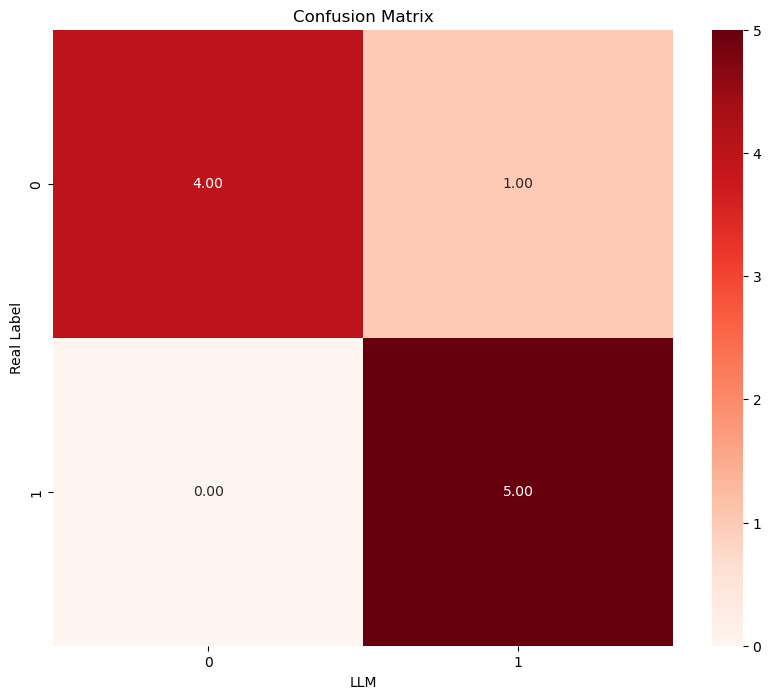

In [ ]:
# Confusion Matrix

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(df_sample['Sentiment'], responses), cmap='Reds', annot=True, fmt='.2f')
plt.title('Confusion Matrix')
plt.xlabel('LLM')
plt.ylabel('Real Label')
plt.show()